In [2]:
from sklearn import datasets
from sklearn.tree import DecisionTreeClassifier


iris = datasets.load_iris()
x = iris["data"][: , 2:]
y = iris["target"]

In [3]:
tree = DecisionTreeClassifier(max_depth= 2 , criterion="entropy")
tree.fit(x , y)

DecisionTreeClassifier(criterion='entropy', max_depth=2)

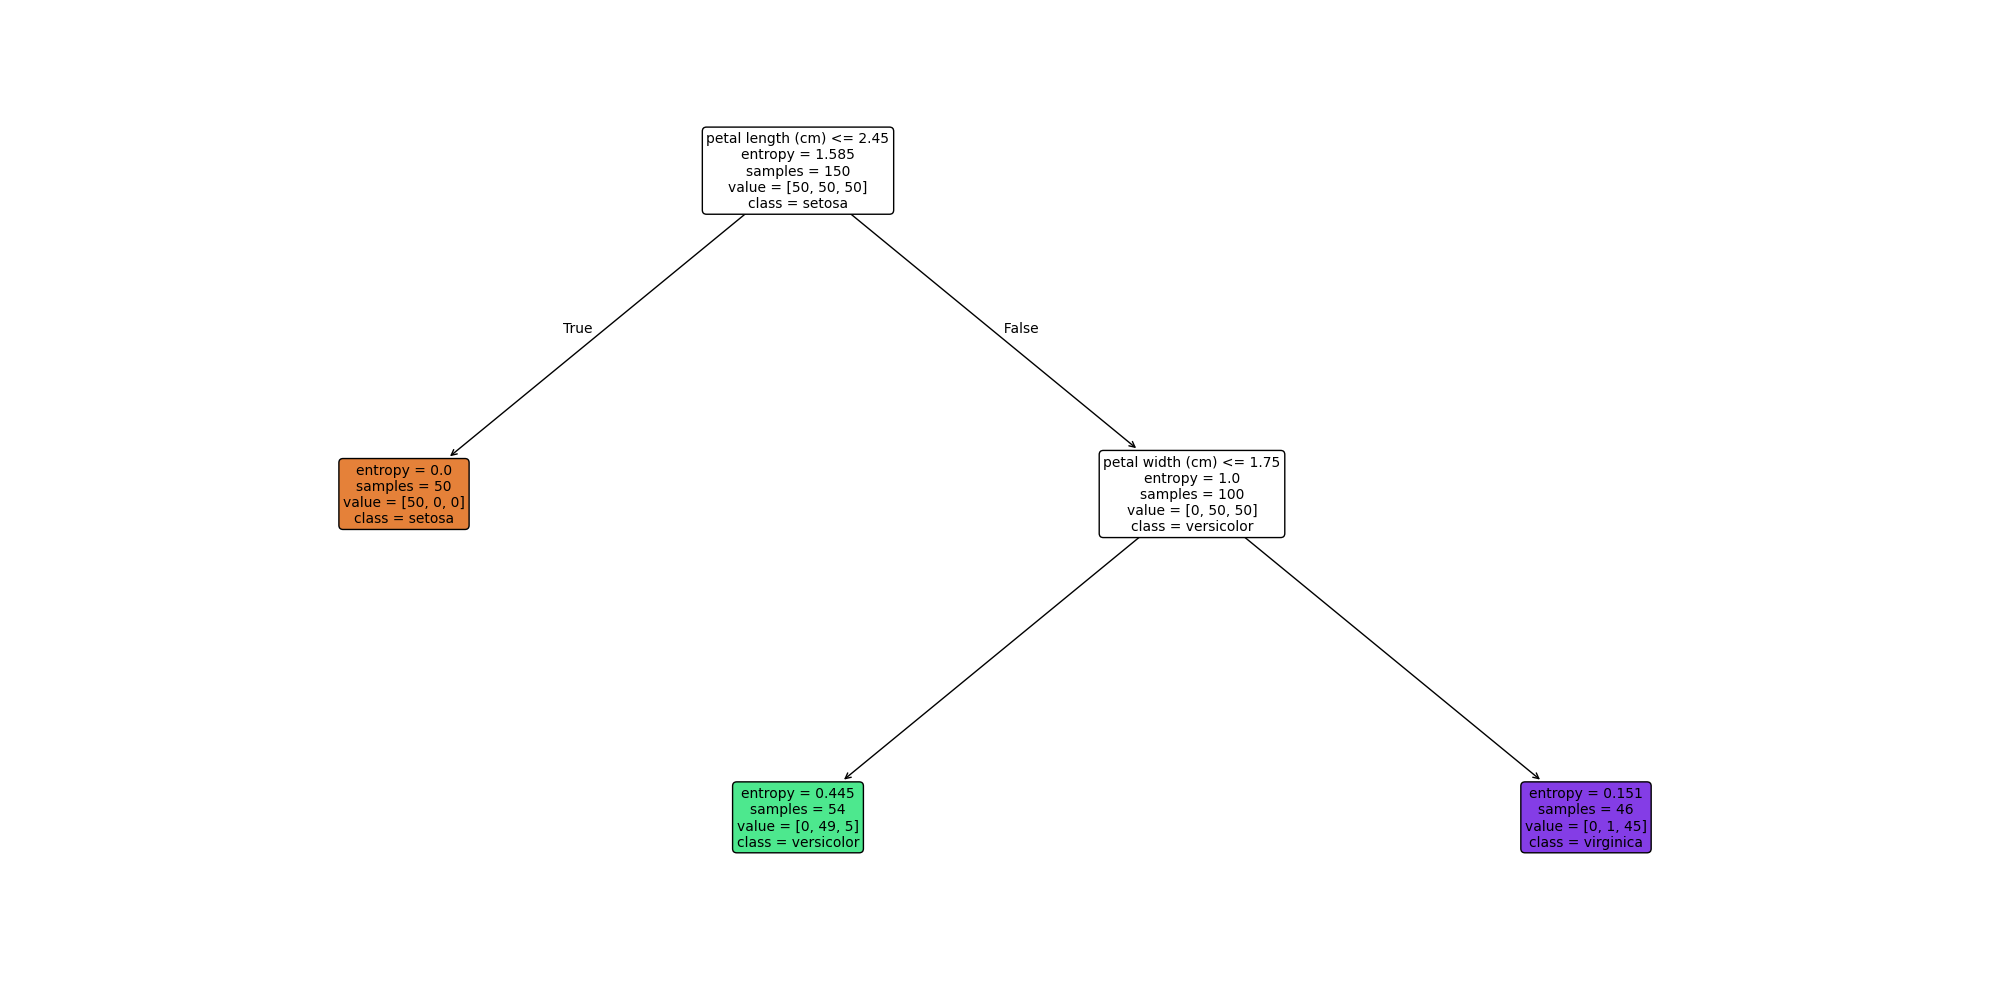

In [4]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
fig , ax = plt.subplots(figsize = (20 , 10))
plot_tree(
    tree ,
    ax= ax,
    feature_names= iris.feature_names[2:],
    class_names= iris.target_names,
    rounded= True,
    filled= True,
    fontsize = 10
)

plt.tight_layout()
plt.savefig("iris_tree.png")
plt.show()

In [5]:
tree.predict_proba([[5 , 1.5]])
tree.predict([[5 , 1.5]])


array([1])

In [31]:
import numpy as np

np.random.seed(42)
x_1 = np.linspace(-3 , 3 , 100).reshape(-1 , 1)
y_1 = x**2 + np.random.normal(0 , 0.5 , x_1.shape)
y_1 = y_1.ravel()

In [44]:
from sklearn.tree import DecisionTreeRegressor

regression = DecisionTreeRegressor(max_depth= 2) #Default hyperparameter
regression.fit(x_1 , y_1)

DecisionTreeRegressor(max_depth=2)

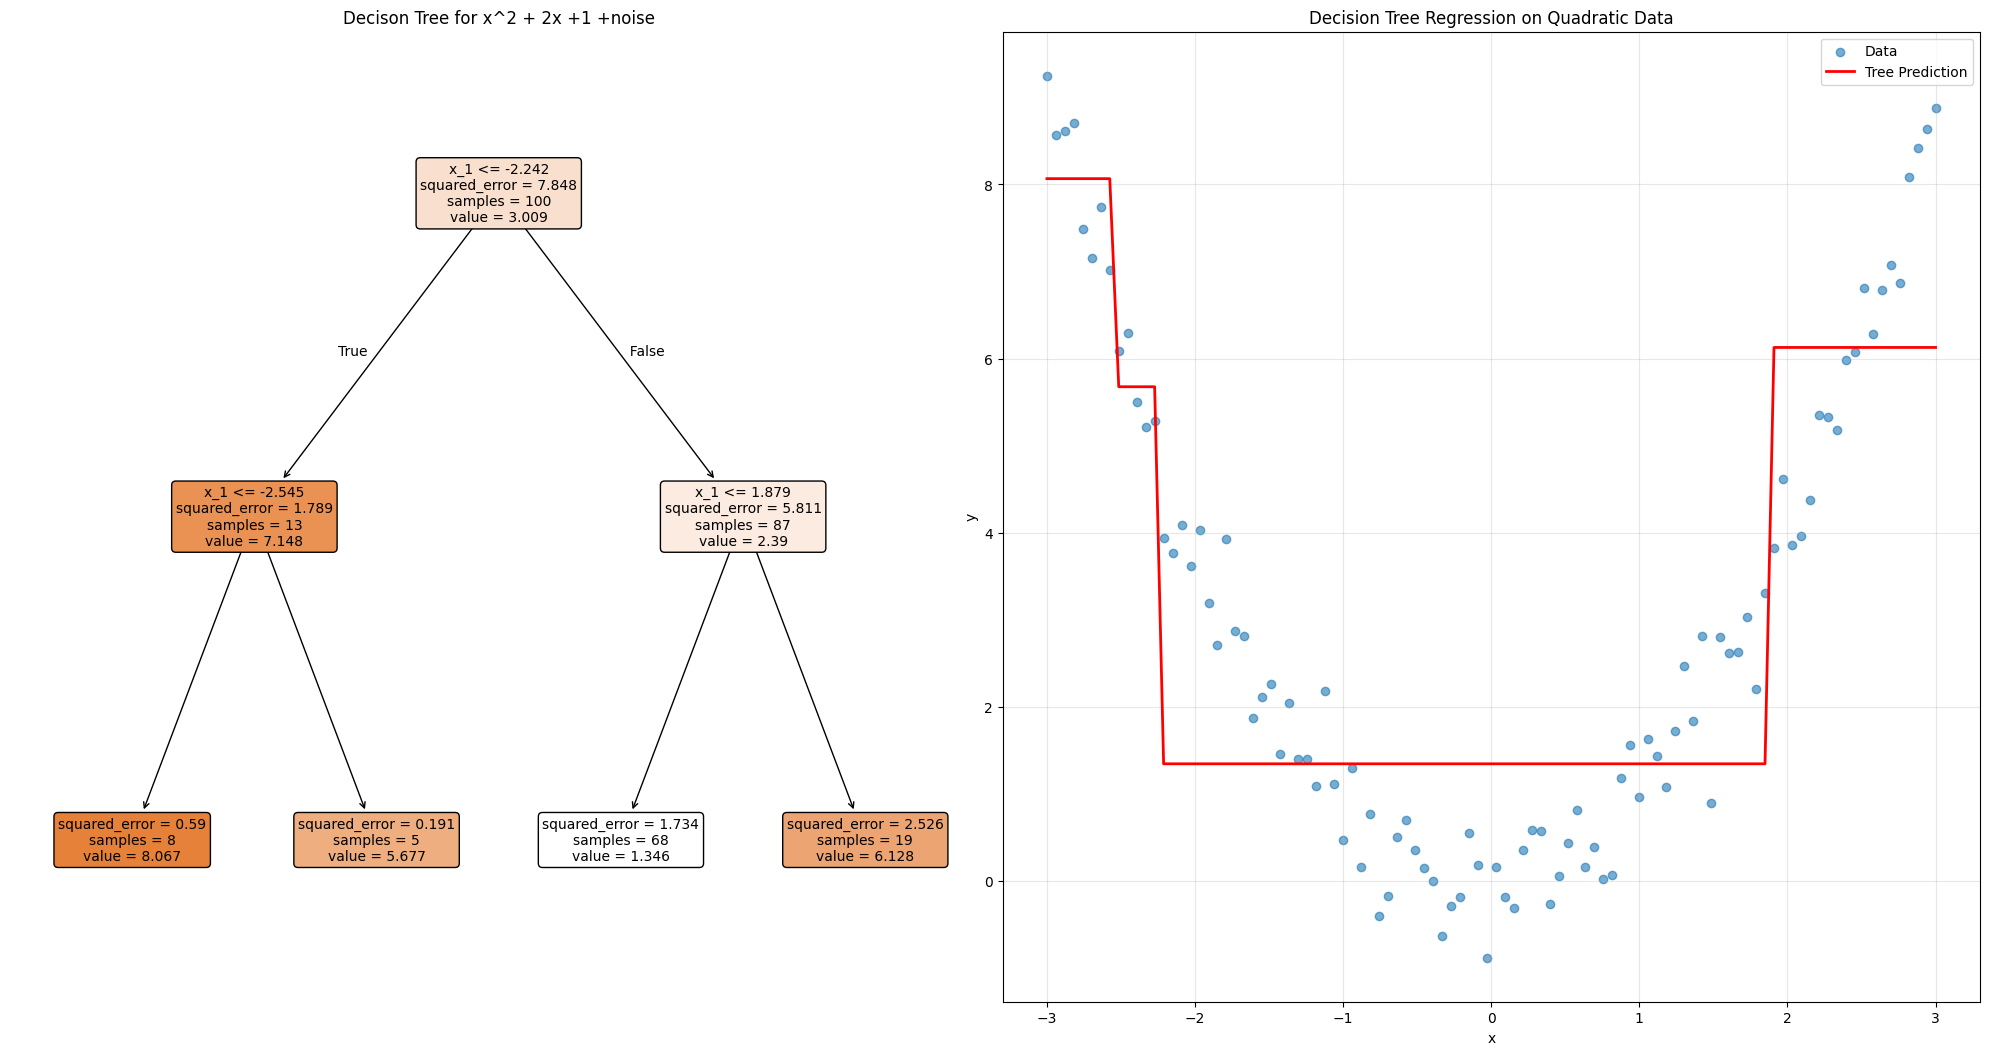

In [69]:
plt.figure(figsize = (20 , 10))
plt.subplot(121)
plot_tree(
        regression ,
        feature_names= ['x_1'],
        rounded= True,
        filled=True,
        fontsize=10
)
plt.tight_layout()
plt.title("Decison Tree for x^2 + 2x +1 +noise")


plt.subplot(122)
plt.scatter(x_1, y_1, alpha=0.6, label='Data')
plt.plot(x_1, regression.predict(x_1), color='red', linewidth=2, label='Tree Prediction')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Decision Tree Regression on Quadratic Data')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


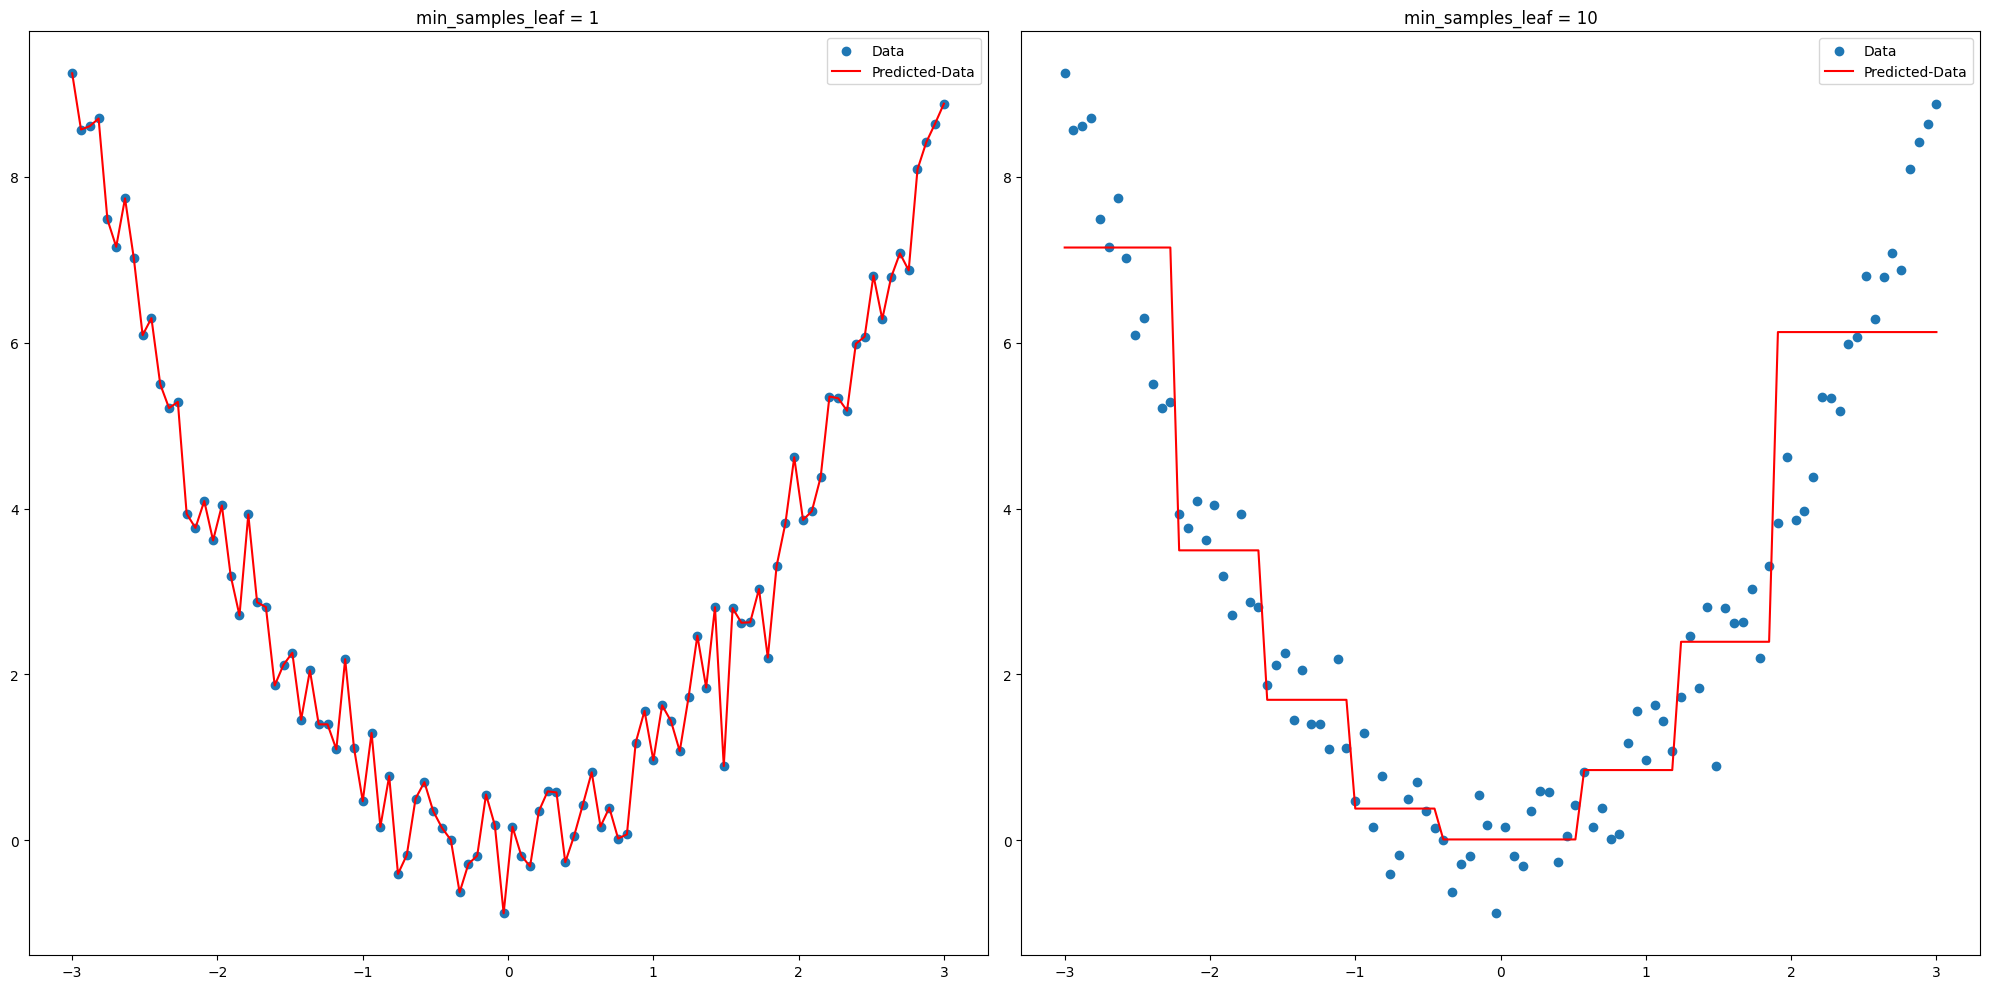

In [70]:
min_samp_leaf = [1, 10]
sub = [121, 122]

plt.figure(figsize=(20, 10))

for min_leaf, sub_1 in zip(min_samp_leaf, sub):
    plt.subplot(sub_1)
    regression_1 = DecisionTreeRegressor(min_samples_leaf=min_leaf)
    regression_1.fit(x_1, y_1)
    plt.scatter(x_1, y_1, label="Data")
    plt.plot(x_1, regression_1.predict(x_1), label="Predicted-Data", color="red")
    plt.legend()
    plt.title(f"min_samples_leaf = {min_leaf}")

plt.tight_layout()
plt.show()